Perform exploratory data analysis (EDA) on Iris dataset to understand its structure. Apply Principal Component Analysis (PCA) for dimensionality reduction. Visualize the transformed dataset and analyze the effectiveness of PCA in reducing the dimensions.

In [48]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt


In [35]:
iris = pd.read_csv("../datasets/Iris.csv")

In [36]:
iris

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [37]:
iris.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [38]:
iris_X = iris.drop(columns=["Id", "Species"])
iris_y = iris["Species"]

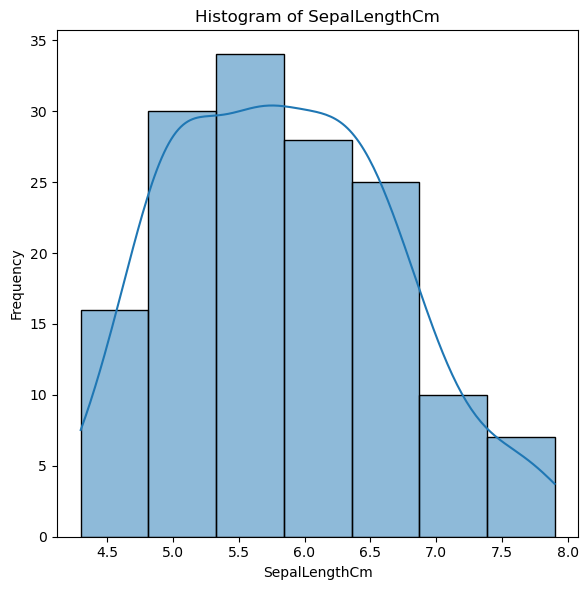

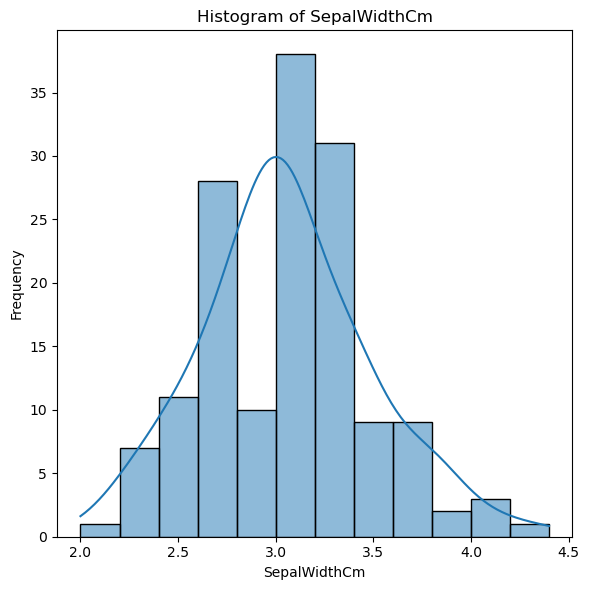

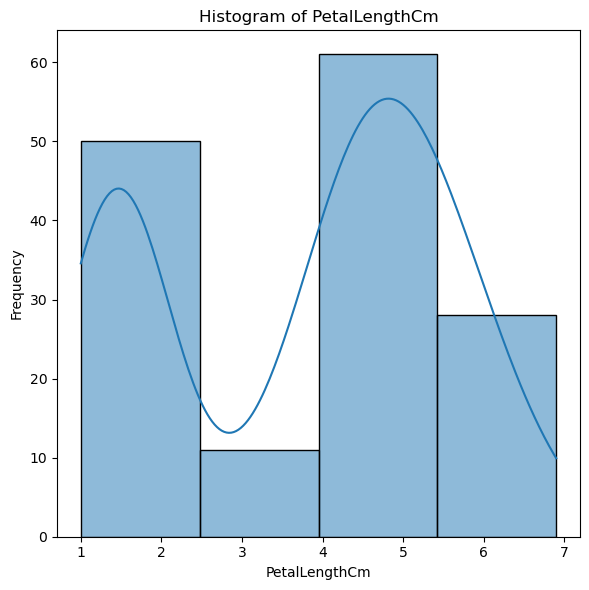

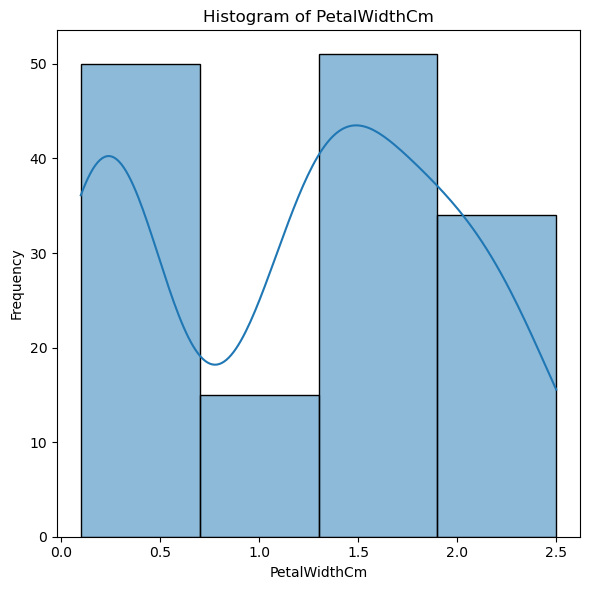

In [39]:
for column in iris_X.columns:
    q1 = iris_X[column].quantile(0.25)
    q3 = iris_X[column].quantile(0.75)
    iqr = q3 - q1

    bin_width = 2 * iqr / (len(iris_X) ** (1 / 3))

    bins = int((iris_X[column].max() - iris_X[column].min()) / bin_width)
    plt.figure(figsize=(6, 6))
    sns.histplot(iris_X[column], bins=bins, kde=True)
    plt.title(f"Histogram of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


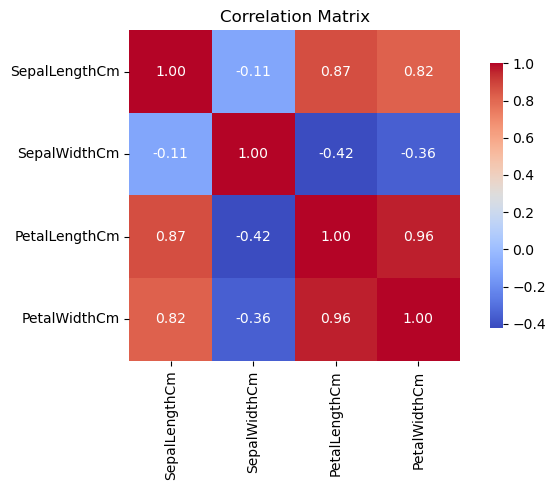

In [40]:
corr = iris_X.corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True, cbar_kws={"shrink": .8})
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

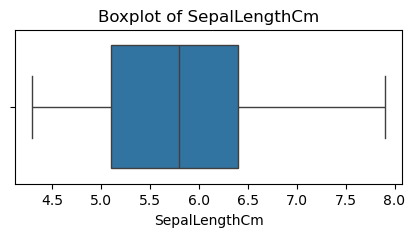

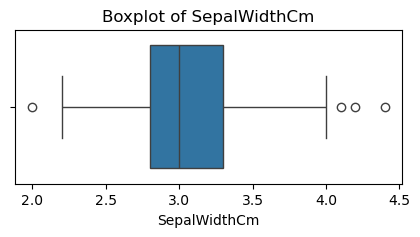

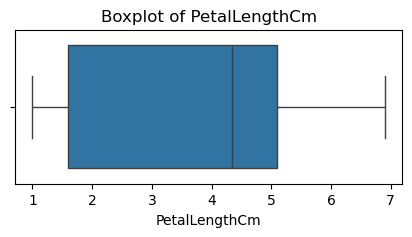

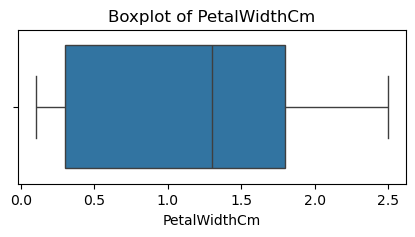

In [41]:
for column in iris_X.columns:
    plt.figure(figsize=(5, 2))
    sns.boxplot(x=iris[column])
    plt.title(f'Boxplot of {column}')
    plt.xlabel(column)
    plt.show()

In [8]:
def remove_outlier(df, columns):
    df_copy = df.copy()
    for column in columns:
        q1 = df[column].quantile(0.25)
        q3 = df[column].quantile(0.75)
        iqr = q3 - q1

        upper_limit = q3 + (1.5 * iqr)
        lower_limit = q1 - (1.5 * iqr)

        df_copy.loc[df[column] > upper_limit, column] = upper_limit
        df_copy.loc[df[column] < lower_limit, column] = lower_limit
    return df_copy

In [10]:
iris_X = remove_outlier(iris_X, iris_X.columns)

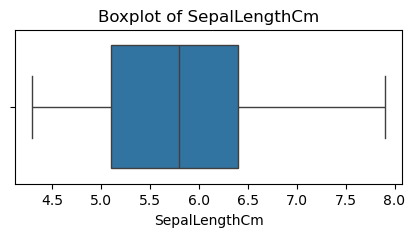

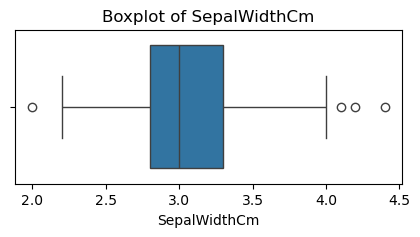

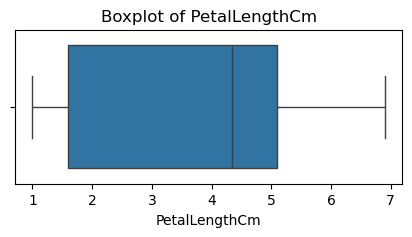

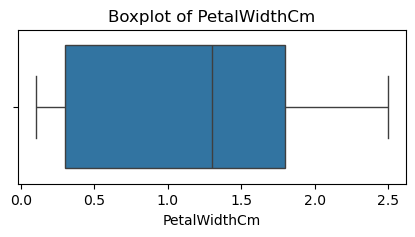

In [42]:
for column in iris_X.columns:
    plt.figure(figsize=(5, 2))
    sns.boxplot(x=iris[column])
    plt.title(f'Boxplot of {column}')
    plt.xlabel(column)
    plt.show()

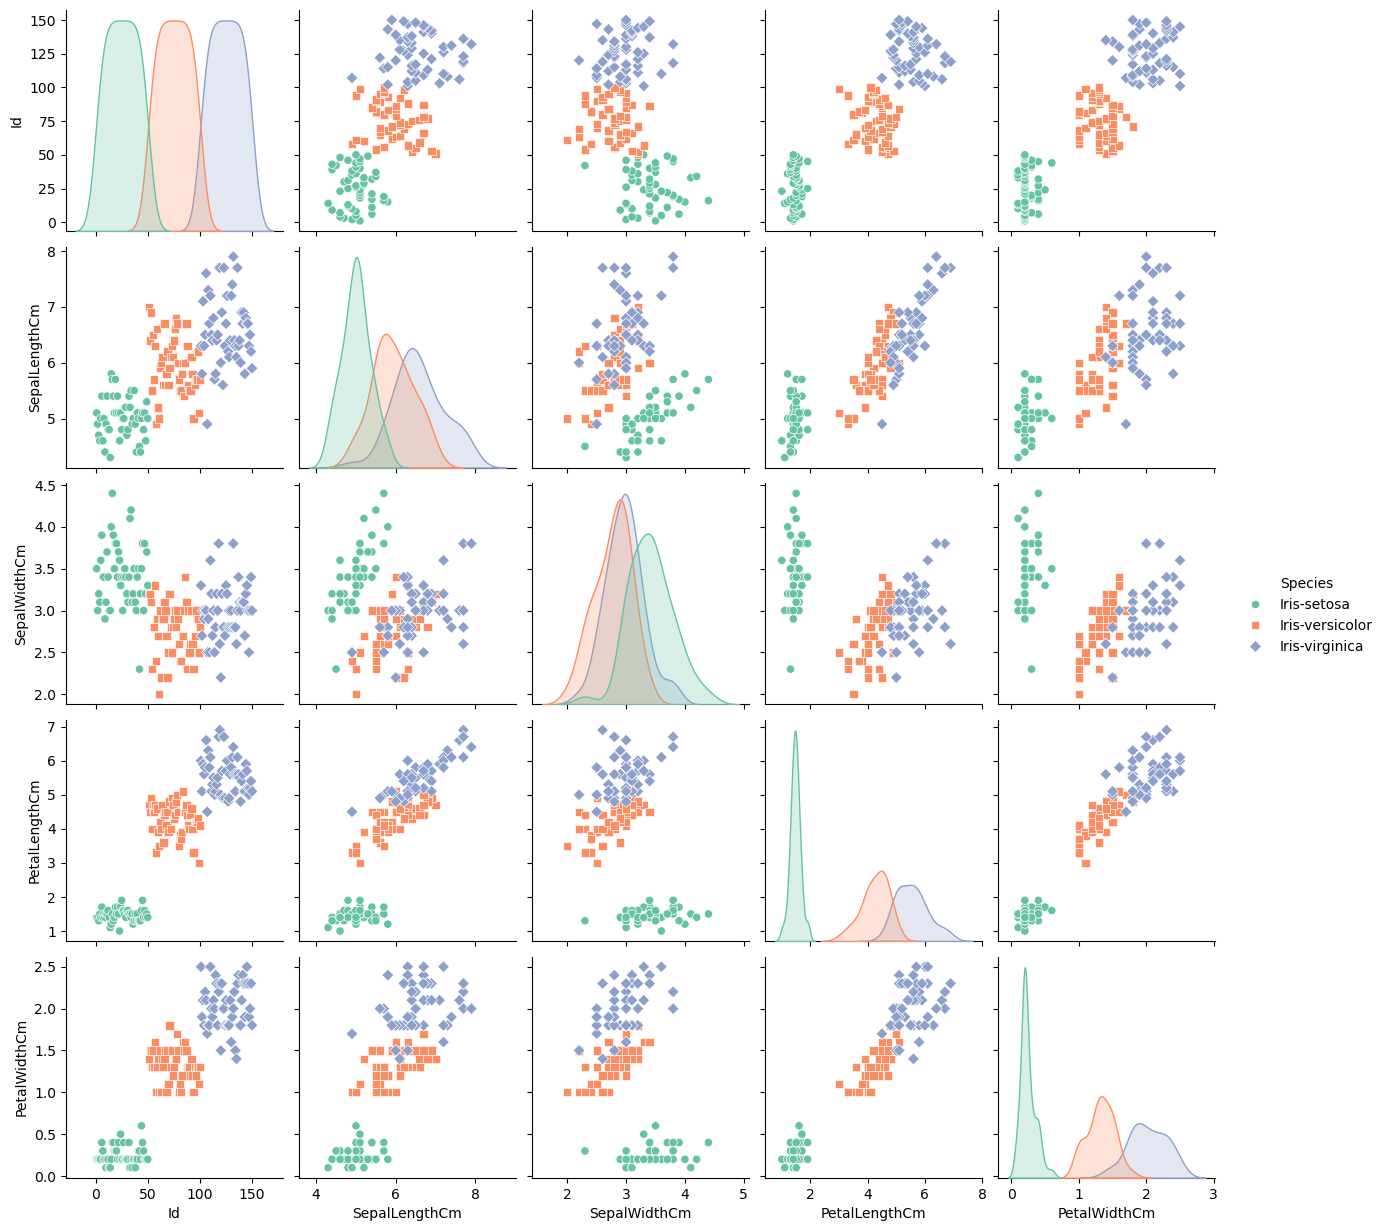

In [43]:
sns.pairplot(iris, hue="Species", markers=["o", "s", "D"], palette="Set2")

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(iris_X, iris_y, test_size=0.2, random_state=42)

In [45]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

Explained variance by PCA components: [0.9195717  0.05707944]


Text(0, 0.5, 'Principal Component 2')

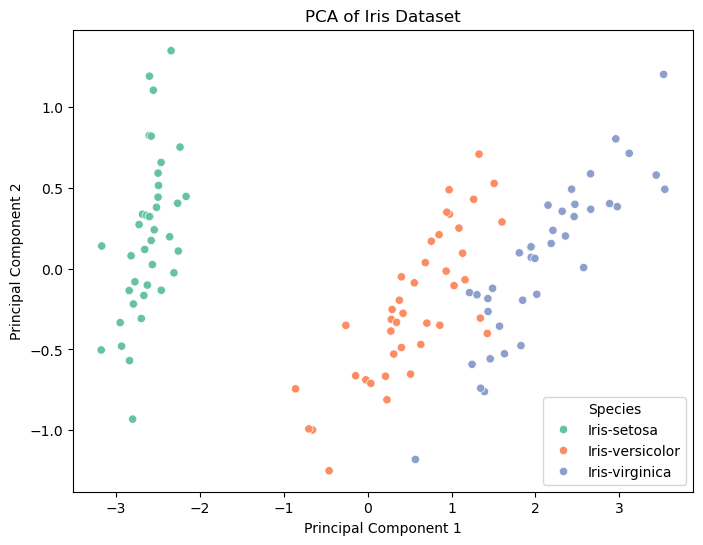

In [57]:
explained_variance = pca.explained_variance_ratio_
print(f"Explained variance by PCA components: {explained_variance}")
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_train_pca[:, 0], y=X_train_pca[:, 1], hue=y_train, palette="Set2")
plt.title("PCA of Iris Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")


<Axes: >

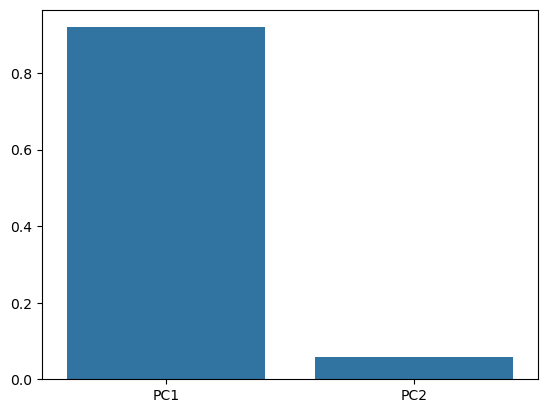

In [58]:
x = [f"PC{i}" for i in range(1, len(pca.explained_variance_ratio_) + 1)]
sns.barplot(x=x, y=explained_variance)

In [46]:
log_model = LogisticRegression(solver='newton-cholesky')

In [47]:
log_model.fit(X_train_pca, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'newton-cholesky'
,max_iter,100
,multi_class,'deprecated'


Accuracy: 1.0
Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



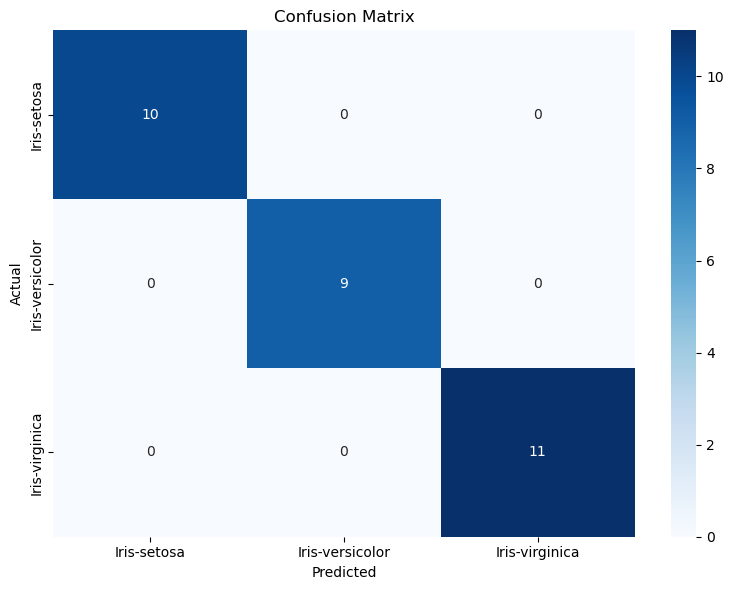

In [51]:
pred_01 = log_model.predict(X_test_pca)


accuracy = accuracy_score(y_test, pred_01)
print("Accuracy:", accuracy)
conf_matrix = confusion_matrix(y_test, pred_01)
print("Classification Report:\n", classification_report(y_test, pred_01))
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris_y.unique(), yticklabels=iris_y.unique())
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [52]:
log_model_02 = LogisticRegression(solver='newton-cholesky')
log_model_02.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'newton-cholesky'
,max_iter,100
,multi_class,'deprecated'


Accuracy without PCA: 1.0
Classification Report without PCA:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



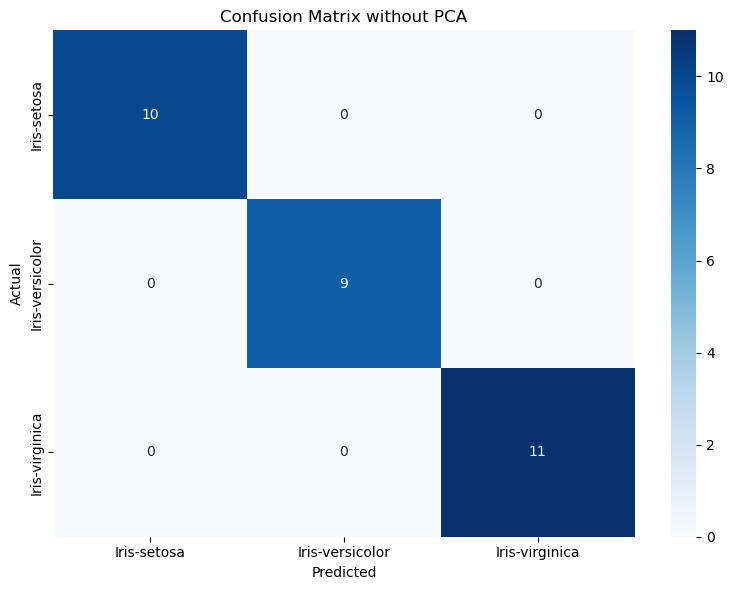

In [53]:
accuracy_02 = accuracy_score(y_test, log_model_02.predict(X_test))
print("Accuracy without PCA:", accuracy_02)
conf_matrix_02 = confusion_matrix(y_test, log_model_02.predict(X_test))
print("Classification Report without PCA:\n", classification_report(y_test, log_model_02.predict(X_test)))
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_02, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris_y.unique(), yticklabels=iris_y.unique())
plt.title('Confusion Matrix without PCA')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()

Basic Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB
None 

Descriptive Statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%         

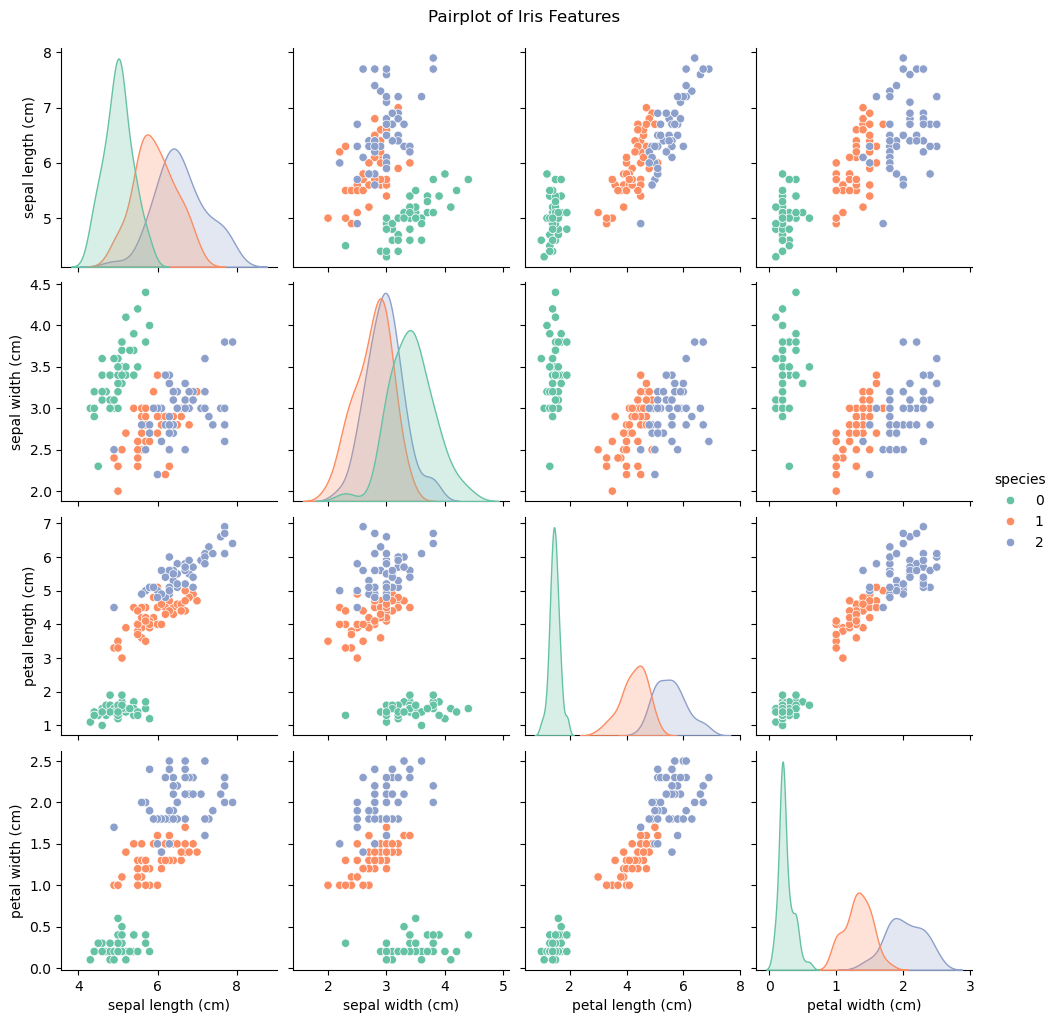

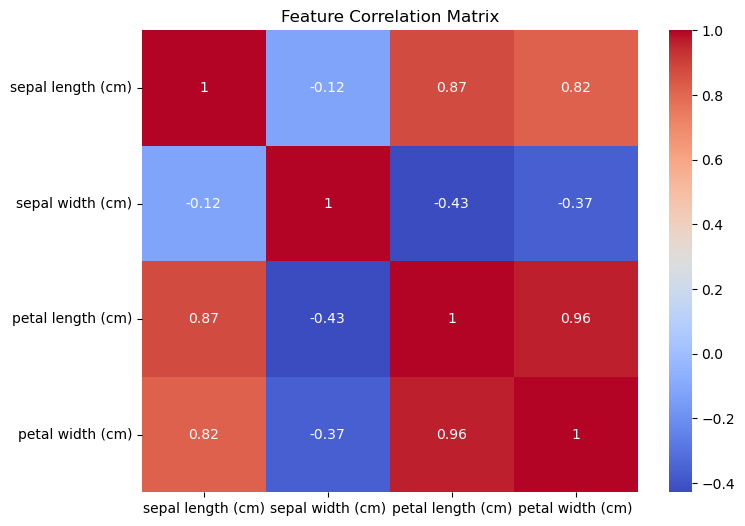

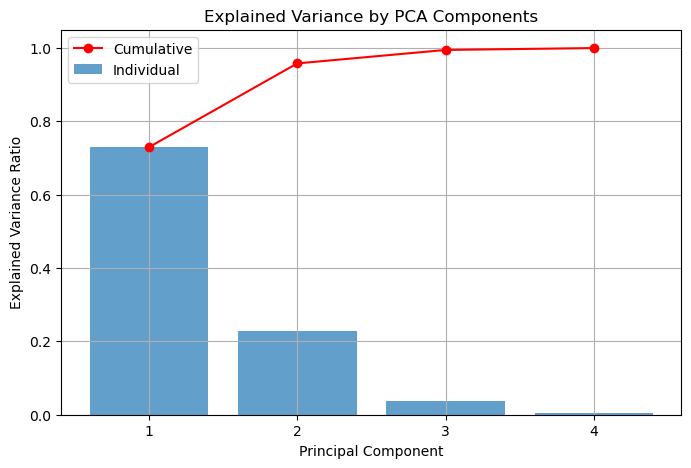

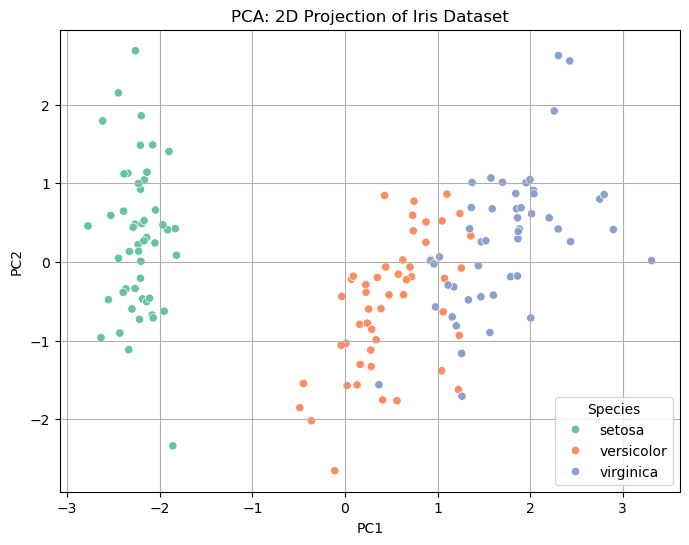

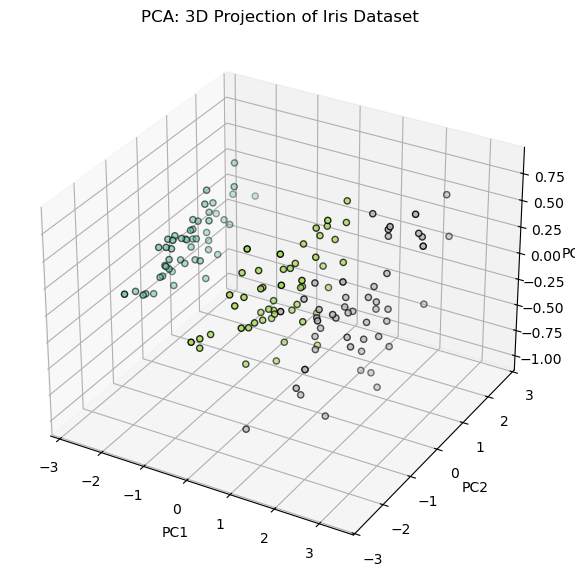

PCA Explained Variance Ratios:
  PC1: 0.7296
  PC2: 0.2285
  PC3: 0.0367
  PC4: 0.0052

Cumulative Variance (first 2 PCs): 95.81%


In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

# Step 1: Load the Iris dataset
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name='species')
species_names = iris.target_names

# Combine features and target for easier EDA
df = pd.concat([X, y], axis=1)

# Step 2: EDA
print("Basic Info:")
print(df.info(), "\n")

print("Descriptive Statistics:")
print(df.describe(), "\n")

print("Value Counts:")
print(df['species'].value_counts(), "\n")

# Pairplot
sns.pairplot(df, hue="species", palette='Set2')
plt.suptitle("Pairplot of Iris Features", y=1.02)
plt.show()

# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

# Step 3: Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 4: Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance
explained_var = pca.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

# Plot explained variance
plt.figure(figsize=(8, 5))
plt.bar(range(1, len(explained_var)+1), explained_var, alpha=0.7, label='Individual')
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o', color='red', label='Cumulative')
plt.xticks(range(1, len(explained_var)+1))
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Component')
plt.title('Explained Variance by PCA Components')
plt.legend()
plt.grid(True)
plt.show()

# Step 5: Visualize the transformed data (2D)
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=species_names[y], palette='Set2')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA: 2D Projection of Iris Dataset')
plt.legend(title='Species')
plt.grid(True)
plt.show()

# Step 6: Optional 3D Visualization
pca_3d = PCA(n_components=3)
X_3d = pca_3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2], c=y, cmap='Set2', edgecolor='k')
ax.set_title("PCA: 3D Projection of Iris Dataset")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
# plt.legend(handles=scatter.legend_elements()[0], labels=species_names, title="Species")
plt.show()

# Step 7: PCA Effectiveness Summary
print("PCA Explained Variance Ratios:")
for i, ratio in enumerate(explained_var):
    print(f"  PC{i+1}: {ratio:.4f}")

print("\nCumulative Variance (first 2 PCs): {:.2f}%".format(cum_var[1] * 100))
